# MODIS Random Forest Regression Analysis (Green/Red Bands Only)

This notebook implements Random Forest regression using only Green and Red bands with:

- Linear features: red and green bands and combinations of ratios and differences
- Log-transformed features: log(red), log(green), log(ratio)
- Derived features: normalized difference, squared terms, products
- 5-day matching window for satellite-insitu pairing
- Feature importance analysis to identify best predictors
- Cross-validation for performance assessment

In [1]:
# Import libraries and utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import all functions from the merged utilities module
from modis_calibration_utils import (
    # Random Forest functions
    match_satellite_insitu_5day,
    prepare_rf_features,
    calibrate_random_forest,
    apply_random_forest,
    plot_rf_analysis,
    # Comparison functions for benchmarking
    calibrate_greenred_model,
    apply_greenred_calibration,
    # Other utilities
    create_time_series_plot,
    export_calibrated_data,
    load_detroit_ysi_data
)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
print("MODIS Random Forest Analysis - Libraries loaded successfully!")

MODIS Random Forest Analysis - Libraries loaded successfully!


## 1. Load UKL in situ data using existing function

In [2]:
try:
    from load_ukl_data import load_ukl_insitu_data, filter_ukl_data_for_satellite_calibration
    
    # Load in situ UKL data using existing function
    raw_ukl_data = load_ukl_insitu_data()
    if len(raw_ukl_data) == 0:
        raise Exception("No UKL data loaded")
    
    # Filter for satellite calibration
    ukl_insitu = filter_ukl_data_for_satellite_calibration(raw_ukl_data, min_chl=1.0, max_chl=350.0)
    
    # Ensure proper column names
    if 'datetime' not in ukl_insitu.columns and 'date' in ukl_insitu.columns:
        ukl_insitu['datetime'] = pd.to_datetime(ukl_insitu['date'])
    
    print(f"In situ UKL data loaded: {len(ukl_insitu)} records")
    print(f"Date range: {ukl_insitu['datetime'].min()} to {ukl_insitu['datetime'].max()}")
    print(f"Chlorophyll range: {ukl_insitu['chlorophyll_ugL'].min():.1f} - {ukl_insitu['chlorophyll_ugL'].max():.1f} µg/L")
    
except Exception as e:
    print(f"Could not load UKL data using load_ukl_data.py: {e}")
    print("Falling back to CSV file loading...")
    
    # Fallback to direct CSV loading
    try:
        ukl_csv_path = 'UKL_insitu_chlorophyll.csv'
        raw_data = pd.read_csv(ukl_csv_path)
        raw_data['datetime'] = pd.to_datetime(raw_data['date'], errors='coerce')
        raw_data = raw_data.dropna(subset=['datetime', 'chlorophyll_ugL'])
        
        # Filter for satellite calibration
        ukl_insitu = raw_data[
            (raw_data['chlorophyll_ugL'] >= 1.0) & 
            (raw_data['chlorophyll_ugL'] <= 350.0)
        ].copy()
        
        print(f"UKL data loaded from CSV: {len(ukl_insitu)} records")
        
    except Exception as e2:
        print(f"Error loading UKL data from CSV: {e2}")
        ukl_insitu = None

# Load Detroit YSI data
print("\nLoading Detroit YSI data...")
detroit_insitu = load_detroit_ysi_data()

Loading UKL in situ data from: /Users/todd/GitHub/ecohydrology/CE-QUAL-W2-HAB-Capabilities/Data/Upper_Klamath_Lake/Klamath K.csv
Found 1486 chlorophyll measurements

Data Summary:
Date range: 2011-04-18 00:00:00 to 2018-10-23 00:00:00
Chlorophyll range: 0.8 - 1341.3 µg/L
Mean chlorophyll: 57.5 µg/L
Median chlorophyll: 23.9 µg/L
Organizations: ['CEDEN' 'KLAMATHTRIBES_WQX']
Number of unique locations: 22
Filtering results:
  Initial records: 1486
  Final records: 1469
  Removed: 17 (1.1%)
In situ UKL data loaded: 1469 records
Date range: 2011-04-18 00:00:00 to 2018-10-23 00:00:00
Chlorophyll range: 1.6 - 344.4 µg/L

Loading Detroit YSI data...
Detroit YSI data loaded: 7029 measurements
Date range: 2010-06-29 10:21:00 to 2022-09-06 11:15:53
Chlorophyll range: 0.0 - 17.4 µg/L


## 2. Load MODIS Satellite Data

In [3]:
# Load MODIS satellite data
def load_modis_data(file_paths):
    """
    Load MODIS data from multiple files
    
    Args:
        file_paths: Dictionary with sensor names as keys and file paths as values
    """
    modis_data = {}
    
    for sensor_name, file_path in file_paths.items():
        try:
            df = pd.read_csv(file_path)
            df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
            df = df.dropna(subset=['datetime'])
            df = df.sort_values('datetime').reset_index(drop=True)
            
            # Add sensor label
            df['sensor'] = sensor_name
            
            modis_data[sensor_name] = df
            print(f"{sensor_name}: {len(df)} records")
            
        except Exception as e:
            print(f"Error loading {sensor_name} data: {e}")
            modis_data[sensor_name] = None
    
    return modis_data

# Define file paths - UPDATE THESE TO MATCH YOUR FILE STRUCTURE
ukl_files = {
    'UKL-Terra': 'UKL_MODIS_Multiband_Terra.csv',
    'UKL-Aqua': 'UKL_MODIS_Multiband_Aqua.csv'
}

detroit_files = {
    'Detroit-Terra': 'Detroit_Mid-Lake_MODIS_Multiband_Terra.csv',
    'Detroit-Aqua': 'Detroit_Mid-Lake_MODIS_Multiband_Aqua.csv'
}

print("Loading UKL MODIS data for calibration:")
ukl_modis = load_modis_data(ukl_files)

print("\nLoading Detroit MODIS data for application:")
detroit_modis = load_modis_data(detroit_files)

Loading UKL MODIS data for calibration:
UKL-Terra: 2497 records
UKL-Aqua: 2395 records

Loading Detroit MODIS data for application:
Detroit-Terra: 1931 records
Detroit-Aqua: 2002 records


## 3. Band Ratio Analysis and Calibration

In [4]:
# Analyze different band combinations
def analyze_band_ratios(modis_data, lake_name):
    """Analyze spectral band ratios for a lake"""
    print(f"\n=== {lake_name} Band Ratio Analysis ===")
    
    all_data = []
    for sensor_name, df in modis_data.items():
        if df is not None and len(df) > 0:
            all_data.append(df)
    
    if not all_data:
        print("No data available for analysis")
        return None
    
    # Combine all sensor data
    combined = pd.concat(all_data, ignore_index=True)
    
    # Calculate band ratios
    combined['green_red_ratio'] = combined['band4_green'] / combined['band1_red']
    combined['nir_red_ratio'] = combined['band2_nir'] / combined['band1_red']
    combined['log_green_red'] = np.log10(combined['green_red_ratio'])
    combined['log_nir_red'] = np.log10(combined['nir_red_ratio'])
    
    # Statistics
    print(f"Green/Red ratio: {combined['green_red_ratio'].mean():.3f} ± {combined['green_red_ratio'].std():.3f}")
    print(f"NIR/Red ratio: {combined['nir_red_ratio'].mean():.3f} ± {combined['nir_red_ratio'].std():.3f}")
    print(f"Log Green/Red: {combined['log_green_red'].mean():.3f} ± {combined['log_green_red'].std():.3f}")
    print(f"Log NIR/Red: {combined['log_nir_red'].mean():.3f} ± {combined['log_nir_red'].std():.3f}")
    
    return combined

# Analyze band ratios
ukl_analysis = analyze_band_ratios(ukl_modis, "Upper Klamath Lake")
detroit_analysis = analyze_band_ratios(detroit_modis, "Detroit Lake")


=== Upper Klamath Lake Band Ratio Analysis ===
Green/Red ratio: 1.485 ± 2.420
NIR/Red ratio: 0.643 ± 2.299
Log Green/Red: 0.138 ± 0.123
Log NIR/Red: -0.360 ± 0.319

=== Detroit Lake Band Ratio Analysis ===
Green/Red ratio: 1.515 ± 0.318
NIR/Red ratio: 4.751 ± 2.437
Log Green/Red: 0.170 ± 0.095
Log NIR/Red: 0.627 ± 0.213


## 4. Random Forest Calibration with 5-Day Matching Window

In [5]:
# Enhanced matching with 5-day window
print("=== MATCHING SATELLITE AND IN SITU DATA (5-DAY WINDOW) ===")

# Match satellite and in situ data with 5-day window
print("\nMatching satellite data with in situ measurements (5-day window)...")

all_ukl_matches_5day = []

for sensor_name, modis_df in ukl_modis.items():
    if modis_df is not None and len(modis_df) > 0:
        print(f"\nProcessing {sensor_name}:")
        
        # Use 5-day matching window
        matches_5day = match_satellite_insitu_5day(
            modis_df, 
            ukl_insitu, 
            temporal_window_days=5
        )
        
        if len(matches_5day) > 0:
            matches_5day['sensor_name'] = sensor_name
            all_ukl_matches_5day.append(matches_5day)
            print(f"  5-day matches: {len(matches_5day)}")
            
            # Show temporal distribution
            avg_time_diff = matches_5day['time_diff_days'].mean()
            max_time_diff = matches_5day['time_diff_days'].max()
            print(f"  Average time difference: {avg_time_diff:.1f} days")
            print(f"  Maximum time difference: {max_time_diff:.1f} days")
        else:
            print(f"  No matches found for {sensor_name}")

if all_ukl_matches_5day:
    ukl_matched_5day = pd.concat(all_ukl_matches_5day, ignore_index=True)
    print(f"\nTotal 5-day matched pairs: {len(ukl_matched_5day)}")
    
    # Show overall statistics
    print(f"Time difference statistics:")
    print(f"  Mean: {ukl_matched_5day['time_diff_days'].mean():.1f} days")
    print(f"  Median: {ukl_matched_5day['time_diff_days'].median():.1f} days") 
    print(f"  Max: {ukl_matched_5day['time_diff_days'].max():.1f} days")
    
else:
    print("No 5-day matches found - check data compatibility")
    ukl_matched_5day = None

=== MATCHING SATELLITE AND IN SITU DATA (5-DAY WINDOW) ===

Matching satellite data with in situ measurements (5-day window)...

Processing UKL-Terra:
  5-day matches: 947
  Average time difference: 2.7 days
  Maximum time difference: 5.0 days

Processing UKL-Aqua:
  5-day matches: 914
  Average time difference: 2.7 days
  Maximum time difference: 5.0 days

Total 5-day matched pairs: 1861
Time difference statistics:
  Mean: 2.7 days
  Median: 3.0 days
  Max: 5.0 days


In [6]:
# First, let's explore the features we'll use for Random Forest
if ukl_matched_5day is not None and len(ukl_matched_5day) > 10:
    # Show the features that will be created
    sample_features = prepare_rf_features(ukl_matched_5day.head(5), include_log=True)
    
    print("=" * 80)
    print("RANDOM FOREST FEATURE ENGINEERING")
    print("=" * 80)
    print(f"\nTotal number of features: {sample_features.shape[1]}")
    print("\nFeature categories:")
    print("\n1. Linear features:")
    print("   - red, green, green_red_ratio, green_minus_red, normalized_diff")
    print("\n2. Quadratic features:")
    print("   - green_squared, red_squared, green_red_product")
    print("\n3. Log-transformed features:")
    print("   - log_red, log_green, log_green_red_ratio")
    print("   - log_norm_red, log_norm_green")
    print("\nAll features:", list(sample_features.columns))

RANDOM FOREST FEATURE ENGINEERING

Total number of features: 13

Feature categories:

1. Linear features:
   - red, green, green_red_ratio, green_minus_red, normalized_diff

2. Quadratic features:
   - green_squared, red_squared, green_red_product

3. Log-transformed features:
   - log_red, log_green, log_green_red_ratio
   - log_norm_red, log_norm_green

All features: ['red', 'green', 'green_red_ratio', 'green_minus_red', 'normalized_diff', 'green_squared', 'red_squared', 'green_red_product', 'log_red', 'log_green', 'log_green_red_ratio', 'log_norm_red', 'log_norm_green']



RANDOM FOREST MODEL TRAINING

Training Random Forest for UKL-Terra...

RANDOM FOREST CALIBRATION (GREEN/RED ONLY): UKL-Terra
Initial clean matches: 947
Number of features: 13
Features: ['red', 'green', 'green_red_ratio', 'green_minus_red', 'normalized_diff', 'green_squared', 'red_squared', 'green_red_product', 'log_red', 'log_green', 'log_green_red_ratio', 'log_norm_red', 'log_norm_green']
Outliers detected: 95

Calibration Results:
  Training R²: 0.820
  Cross-validation R²: 0.323 ± 0.103
  RMSE: 30.555 µg/L
  Number of samples: 852

Top 5 Most Important Features:
  green_minus_red: 0.493
  green_red_ratio: 0.102
  normalized_diff: 0.101
  log_green_red_ratio: 0.088
  green_red_product: 0.047


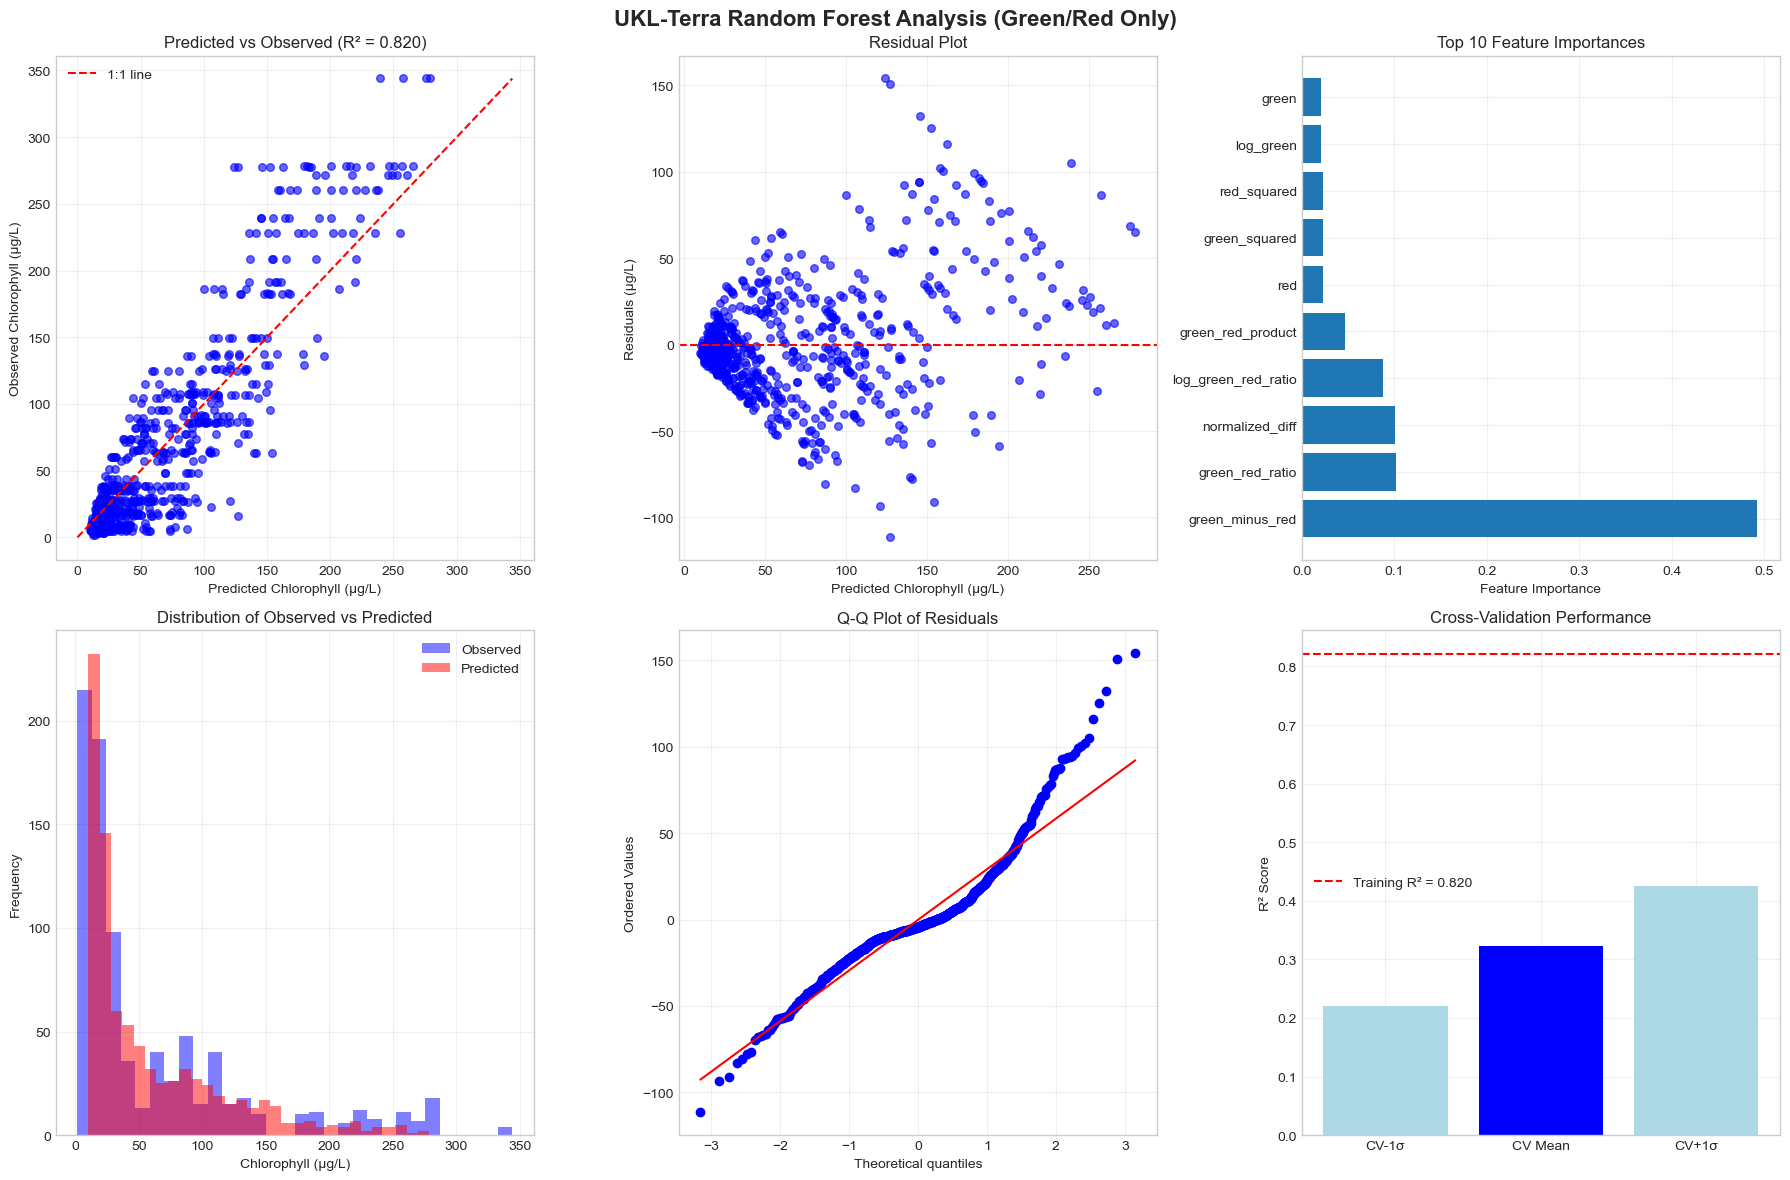

Random Forest analysis plot saved: UKL-Terra_random_forest_analysis.png

Training Random Forest for UKL-Aqua...

RANDOM FOREST CALIBRATION (GREEN/RED ONLY): UKL-Aqua
Initial clean matches: 914
Number of features: 13
Features: ['red', 'green', 'green_red_ratio', 'green_minus_red', 'normalized_diff', 'green_squared', 'red_squared', 'green_red_product', 'log_red', 'log_green', 'log_green_red_ratio', 'log_norm_red', 'log_norm_green']
Outliers detected: 92

Calibration Results:
  Training R²: 0.817
  Cross-validation R²: 0.287 ± 0.121
  RMSE: 29.257 µg/L
  Number of samples: 822

Top 5 Most Important Features:
  green_minus_red: 0.225
  normalized_diff: 0.202
  log_green_red_ratio: 0.180
  green_red_ratio: 0.169
  green_red_product: 0.058


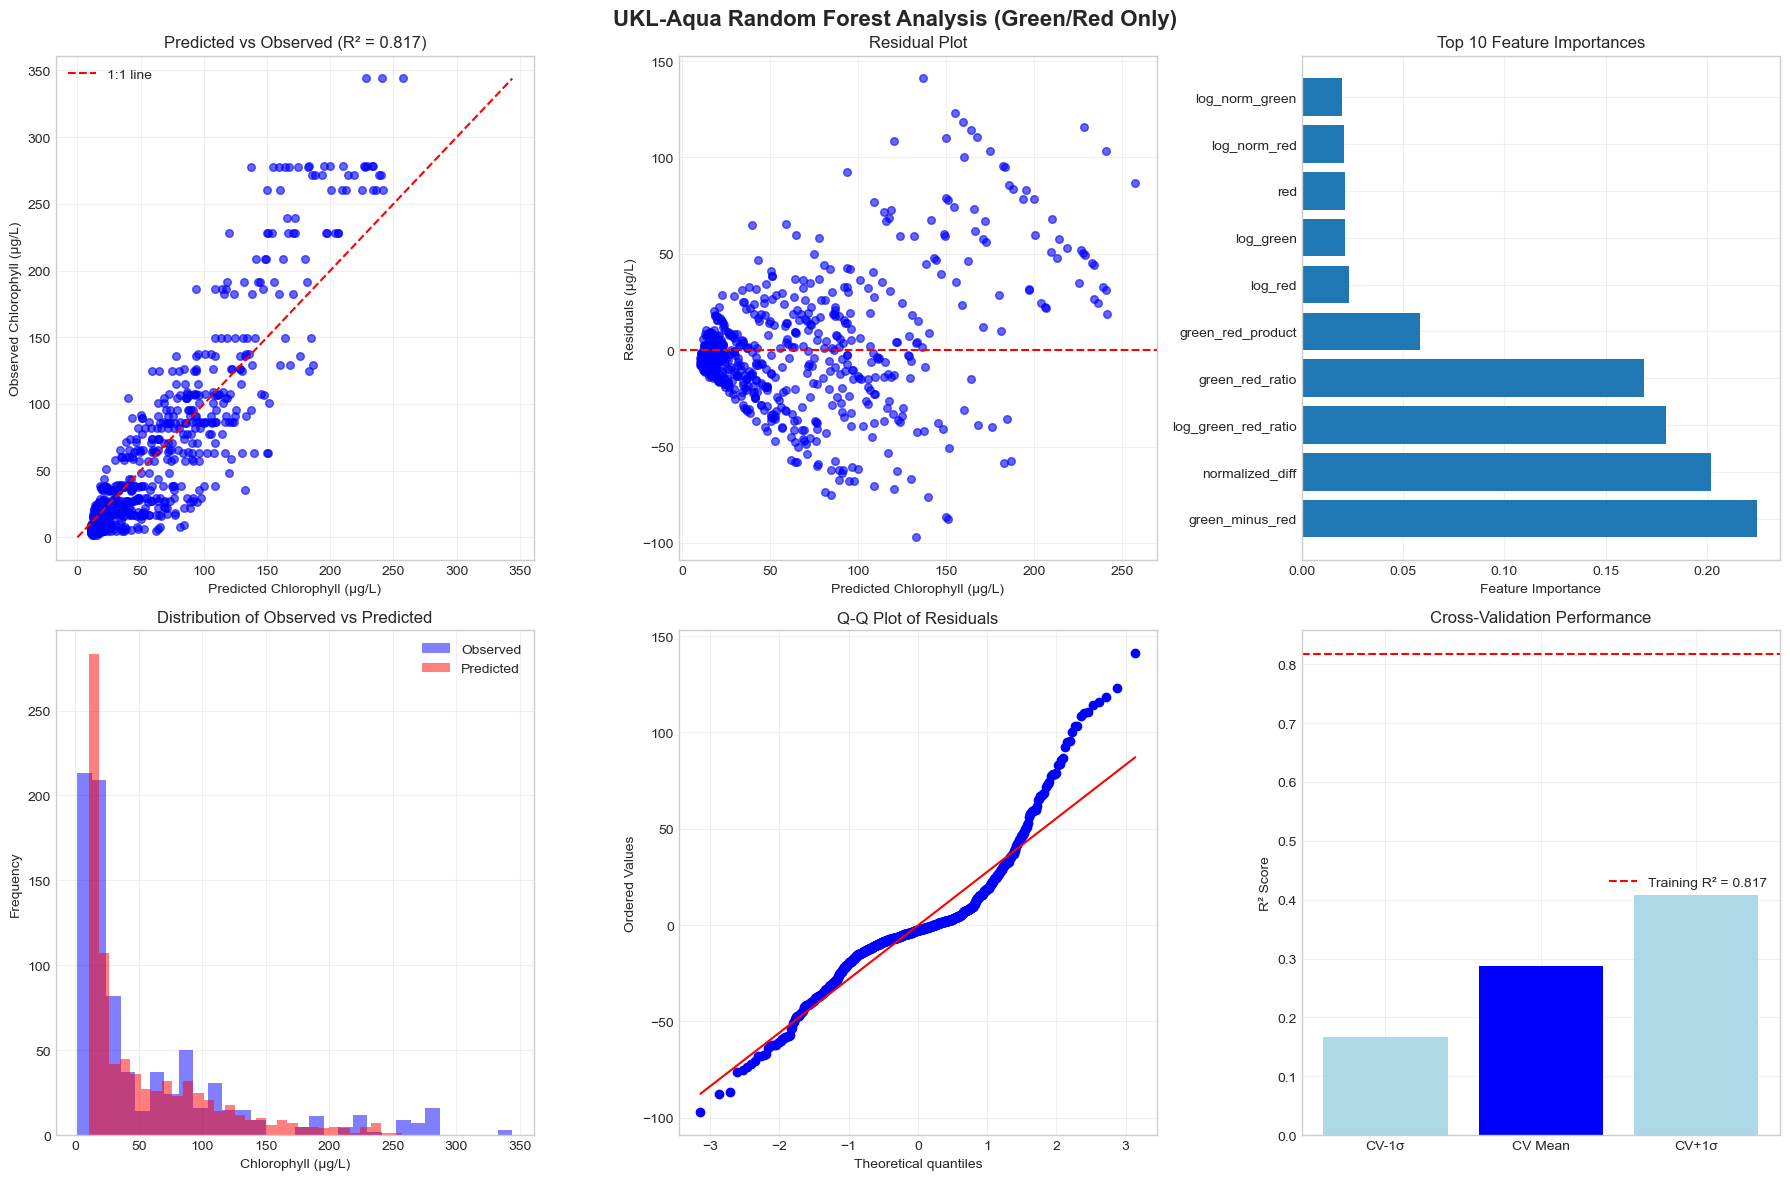

Random Forest analysis plot saved: UKL-Aqua_random_forest_analysis.png

Training Random Forest on combined sensor data...

RANDOM FOREST CALIBRATION (GREEN/RED ONLY): MODIS-Combined
Initial clean matches: 1861
Number of features: 13
Features: ['red', 'green', 'green_red_ratio', 'green_minus_red', 'normalized_diff', 'green_squared', 'red_squared', 'green_red_product', 'log_red', 'log_green', 'log_green_red_ratio', 'log_norm_red', 'log_norm_green']
Outliers detected: 186

Calibration Results:
  Training R²: 0.838
  Cross-validation R²: 0.362 ± 0.052
  RMSE: 28.036 µg/L
  Number of samples: 1675

Top 5 Most Important Features:
  green_minus_red: 0.389
  green_red_ratio: 0.136
  normalized_diff: 0.125
  log_green_red_ratio: 0.117
  green_red_product: 0.055


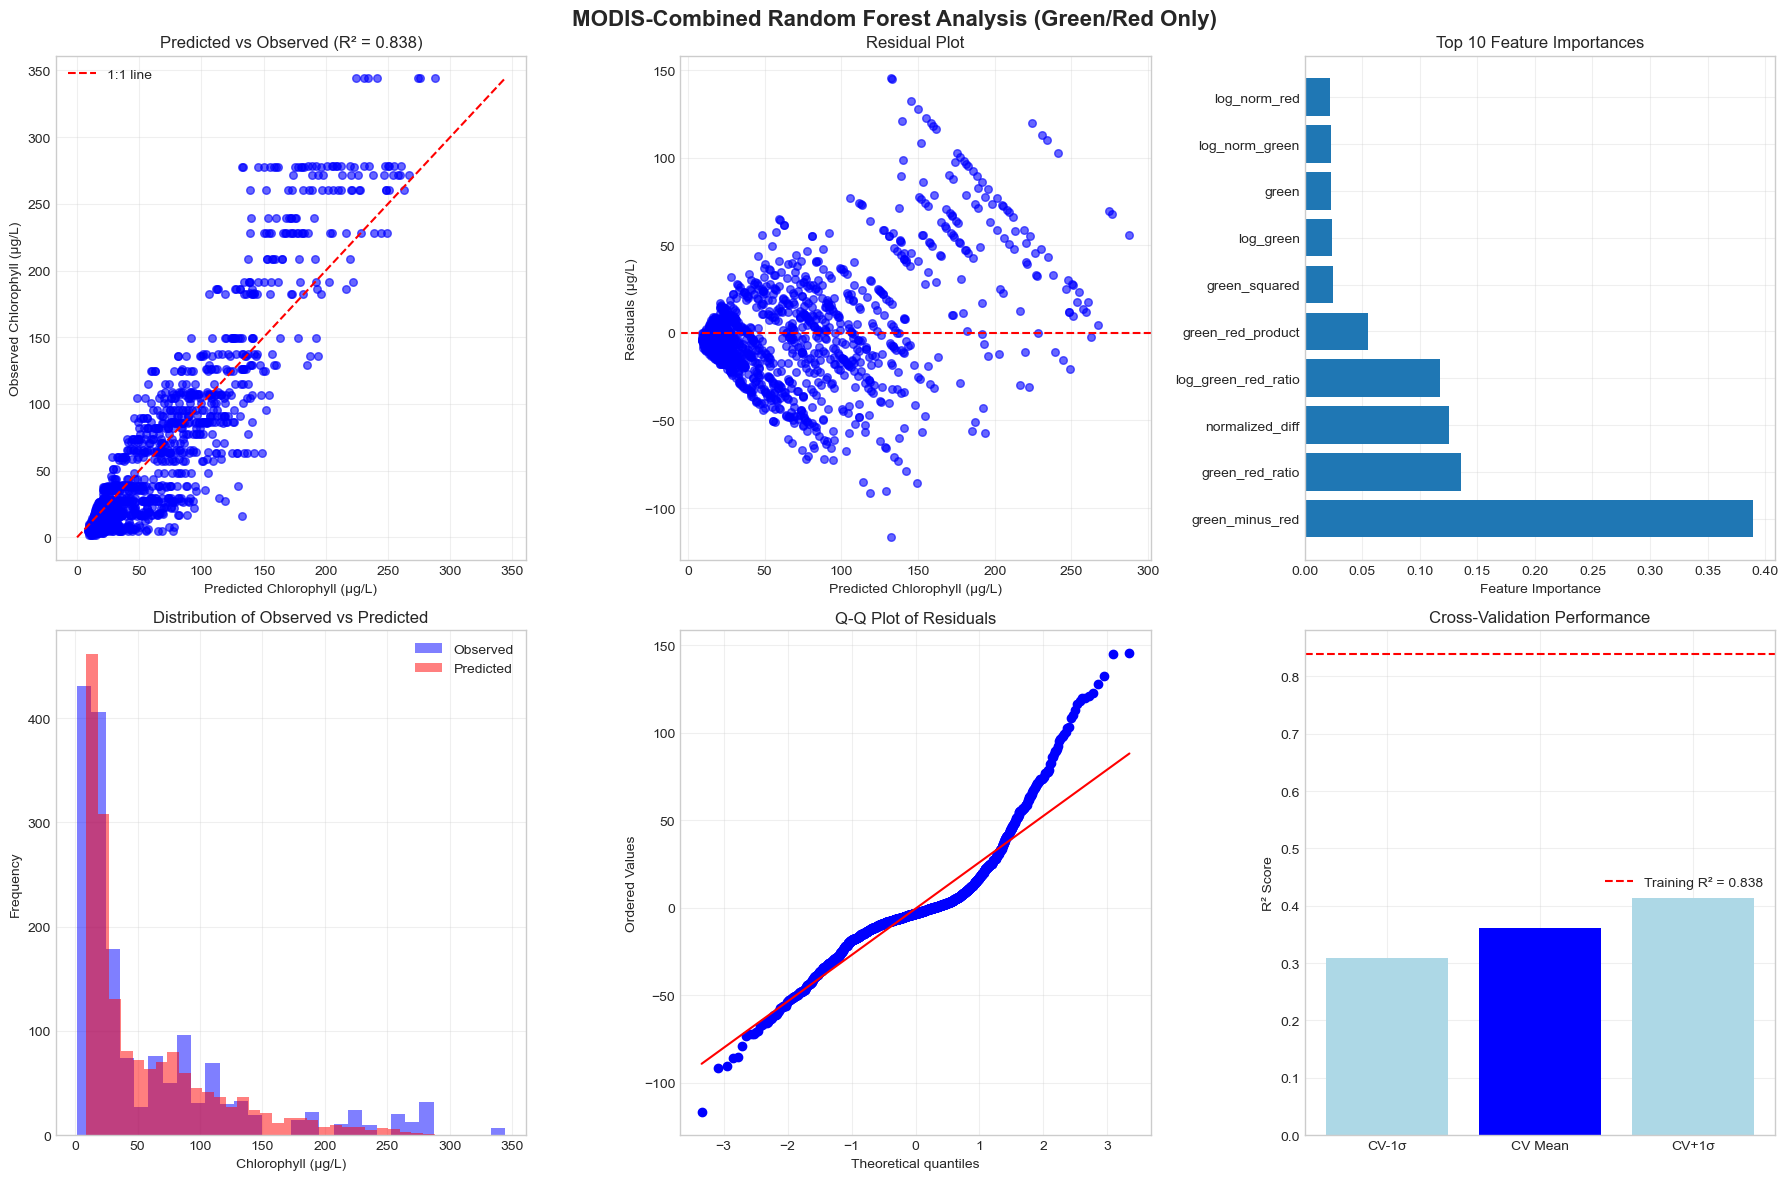

Random Forest analysis plot saved: MODIS-Combined_random_forest_analysis.png


In [7]:
# Train Random Forest models for each sensor and combined data
rf_results = {}

if ukl_matched_5day is not None and len(ukl_matched_5day) > 0:
    print("\n" + "=" * 80)
    print("RANDOM FOREST MODEL TRAINING")
    print("=" * 80)
    
    # Train for each sensor separately
    for sensor_name in ukl_matched_5day['sensor_name'].unique():
        sensor_data = ukl_matched_5day[ukl_matched_5day['sensor_name'] == sensor_name]
        
        if len(sensor_data) >= 30:  # Need enough data for Random Forest
            print(f"\nTraining Random Forest for {sensor_name}...")
            
            # Train Random Forest model
            rf_result = calibrate_random_forest(
                sensor_data,
                sensor_name=sensor_name,
                remove_outliers=True,
                n_estimators=100,
                max_depth=10,  # Limit depth to prevent overfitting
                min_samples_split=5
            )
            
            if rf_result is not None:
                rf_results[sensor_name] = rf_result
                
                # Create detailed analysis plots
                plot_rf_analysis(rf_result, sensor_name)
        else:
            print(f"Not enough data for {sensor_name}: {len(sensor_data)} matches")
    
    # Train on combined data
    if len(ukl_matched_5day) >= 50:  # Need more data for combined model
        print(f"\nTraining Random Forest on combined sensor data...")
        
        combined_rf_result = calibrate_random_forest(
            ukl_matched_5day,
            sensor_name="MODIS-Combined",
            remove_outliers=True,
            n_estimators=200,  # More trees for combined data
            max_depth=15,
            min_samples_split=5
        )
        
        if combined_rf_result is not None:
            rf_results['Combined'] = combined_rf_result
            plot_rf_analysis(combined_rf_result, "MODIS-Combined")
    
else:
    print("No matched data available for Random Forest training")

In [8]:
# Compare Random Forest with simpler Green/Red log model for benchmark
comparison_results = {}

if ukl_matched_5day is not None and len(ukl_matched_5day) > 0:
    print("=" * 80)
    print("MODEL COMPARISON: RANDOM FOREST vs GREEN/RED LOG")
    print("=" * 80)
    
    # Train Green/Red log model for comparison
    greenred_result = calibrate_greenred_model(
        ukl_matched_5day,
        sensor_name="MODIS-Combined",
        remove_outliers=True
    )
    
    # Compare results
    if 'Combined' in rf_results and greenred_result is not None:
        rf = rf_results['Combined']
        gr = greenred_result
        
        print("\n" + "=" * 80)
        print("PERFORMANCE COMPARISON")
        print("=" * 80)
        print(f"{'Model':<20} {'R²':<10} {'CV R²':<15} {'RMSE':<10} {'N':<8}")
        print("-" * 80)
        
        # Random Forest results
        print(f"{'Random Forest':<20} {rf['r2']:<10.3f} {rf['cv_r2_mean']:.3f} ± {rf['cv_r2_std']:.3f}  {rf['rmse']:<10.3f} {rf['n_samples']:<8d}")
        
        # Green/Red log results
        print(f"{'Green/Red Log':<20} {gr['cleaned']['r2']:<10.3f} {'N/A':<15} {gr['cleaned']['rmse']:<10.3f} {gr['cleaned']['n_matches']:<8d}")
        
        print("\n" + "=" * 80)
        print("KEY INSIGHTS:")
        print("=" * 80)
        
        if rf['r2'] > gr['cleaned']['r2']:
            improvement = (rf['r2'] - gr['cleaned']['r2']) / gr['cleaned']['r2'] * 100
            print(f"✅ Random Forest performs {improvement:.1f}% better than Green/Red Log")
        else:
            decline = (gr['cleaned']['r2'] - rf['r2']) / gr['cleaned']['r2'] * 100
            print(f"⚠️ Random Forest performs {decline:.1f}% worse than Green/Red Log")
        
        # Check for overfitting
        if rf['cv_r2_mean'] < rf['r2'] - 0.1:
            print("⚠️ Potential overfitting detected (CV R² much lower than training R²)")
        else:
            print("✅ Good generalization (CV R² close to training R²)")
        
        comparison_results = {
            'random_forest': rf,
            'greenred_log': gr
        }

MODEL COMPARISON: RANDOM FOREST vs GREEN/RED LOG

GREEN/RED ONLY CALIBRATION: MODIS-Combined
Initial clean matches: 1861
Outliers detected: 26

Calibration Results:
  Equation: log10(Chl) = 1.055 + 3.293*log10(B4/B1)
  Original data: 1861 matches, R² = 0.227, RMSE = 0.445
  Cleaned data: 1835 matches, R² = 0.381, RMSE = 0.394
  Improvement: ΔR² = +0.154

PERFORMANCE COMPARISON
Model                R²         CV R²           RMSE       N       
--------------------------------------------------------------------------------
Random Forest        0.838      0.362 ± 0.052  28.036     1675    
Green/Red Log        0.381      N/A             0.394      1835    

KEY INSIGHTS:
✅ Random Forest performs 120.0% better than Green/Red Log
⚠️ Potential overfitting detected (CV R² much lower than training R²)


In [9]:
## 6. Apply Models to Full Datasets

In [10]:
# Apply Random Forest to complete datasets
def apply_rf_to_dataset(modis_data, rf_results, dataset_name):
    """Apply Random Forest calibrations to a complete dataset"""
    print(f"\nApplying Random Forest to {dataset_name}...")
    
    rf_calibrated_data = {}
    
    # Get the best RF model to use
    if 'Combined' in rf_results:
        rf_to_use = rf_results['Combined']
    else:
        # Use the first available sensor's model
        rf_to_use = list(rf_results.values())[0]
    
    for sensor_name, modis_df in modis_data.items():
        if modis_df is None or len(modis_df) == 0:
            continue
            
        print(f"\nProcessing {sensor_name}:")
        
        # Apply Random Forest calibration
        df_calibrated = apply_random_forest(
            modis_df,
            rf_to_use,
            output_col='chl_rf'
        )
        
        rf_calibrated_data[sensor_name] = df_calibrated
        print(f"  Applied to {len(df_calibrated)} valid observations")
        
        # Show statistics
        if len(df_calibrated) > 0:
            chl_stats = df_calibrated['chl_rf'].describe()
            print(f"  Chlorophyll range: {chl_stats['min']:.1f} - {chl_stats['max']:.1f} µg/L")
            print(f"  Mean: {chl_stats['mean']:.1f} µg/L")
            print(f"  Median: {chl_stats['50%']:.1f} µg/L")
    
    return rf_calibrated_data

# Apply models
if rf_results:
    ukl_rf_calibrated = apply_rf_to_dataset(ukl_modis, rf_results, "UKL")
    detroit_rf_calibrated = apply_rf_to_dataset(detroit_modis, rf_results, "Detroit")
    
    # Also apply Green/Red log model for comparison
    if 'greenred_log' in comparison_results:
        gr_result = comparison_results['greenred_log']
        
        print("\n" + "=" * 80)
        print("Applying Green/Red Log model for comparison...")
        
        ukl_gr_calibrated = {}
        detroit_gr_calibrated = {}
        
        for sensor_name, modis_df in ukl_modis.items():
            if modis_df is not None:
                ukl_gr_calibrated[sensor_name] = apply_greenred_calibration(
                    modis_df, gr_result, 'chl_greenred'
                )
        
        for sensor_name, modis_df in detroit_modis.items():
            if modis_df is not None:
                detroit_gr_calibrated[sensor_name] = apply_greenred_calibration(
                    modis_df, gr_result, 'chl_greenred'
                )
else:
    print("No Random Forest results available to apply")


Applying Random Forest to UKL...

Processing UKL-Terra:
  Applied to 2497 valid observations
  Chlorophyll range: 15.2 - 246.9 µg/L
  Mean: 67.4 µg/L
  Median: 47.4 µg/L

Processing UKL-Aqua:
  Applied to 2395 valid observations
  Chlorophyll range: 9.1 - 280.2 µg/L
  Mean: 63.9 µg/L
  Median: 40.2 µg/L

Applying Random Forest to Detroit...

Processing Detroit-Terra:
  Applied to 1931 valid observations
  Chlorophyll range: 21.3 - 205.0 µg/L
  Mean: 71.4 µg/L
  Median: 73.4 µg/L

Processing Detroit-Aqua:
  Applied to 2002 valid observations
  Chlorophyll range: 16.2 - 216.3 µg/L
  Mean: 69.8 µg/L
  Median: 71.4 µg/L

Applying Green/Red Log model for comparison...


In [ ]:
## 7. Create Time Series Visualizations

In [ ]:
# Create time series plots for Random Forest results
def create_rf_time_series(calibrated_data, insitu_data, lake_name, model_type='Random Forest'):
    """Create time series plots for Random Forest or Green/Red calibrations"""
    
    if not calibrated_data:
        print(f"No calibrated data available for {lake_name}")
        return
    
    print(f"\nCreating {model_type} time series plot for {lake_name}...")
    
    # Prepare data dictionary for plotting
    method_data = {}
    col_name = 'chl_rf' if 'Random Forest' in model_type else 'chl_greenred'
    
    for sensor_name, df in calibrated_data.items():
        if df is not None and col_name in df.columns:
            # Create a clean dataset for plotting
            plot_df = df[['datetime', col_name]].copy()
            plot_df = plot_df.rename(columns={col_name: 'chl_calibrated'})
            plot_df = plot_df.dropna(subset=['chl_calibrated'])
            
            # Map sensor names to standard format
            if 'Terra' in sensor_name:
                method_data['MODIS-Terra'] = plot_df
            elif 'Aqua' in sensor_name:
                method_data['MODIS-Aqua'] = plot_df
    
    # Create the plot
    if method_data:
        title = f'{lake_name} - {model_type} Calibrated Satellite Chlorophyll vs In Situ Data'
        filename = f'{lake_name}_{model_type.lower().replace(" ", "_")}_time_series.png'
        
        create_time_series_plot(
            method_data,
            insitu_data,
            title,
            filename,
            lake_name,
            ylim=(0, 400)
        )
        
        # Print data retention statistics
        total_points = sum(len(df) for df in method_data.values())
        print(f"  Total MODIS points plotted: {total_points}")
    else:
        print(f"No data available for {lake_name} time series plot")

# Create Random Forest time series plots
if 'ukl_rf_calibrated' in locals():
    create_rf_time_series(ukl_rf_calibrated, ukl_insitu, "UKL", "Random Forest")
    
if 'detroit_rf_calibrated' in locals():
    detroit_insitu_for_plot = detroit_insitu if 'detroit_insitu' in locals() else None
    create_rf_time_series(detroit_rf_calibrated, detroit_insitu_for_plot, "Detroit", "Random Forest")

# Create Green/Red Log time series plots for comparison
if 'ukl_gr_calibrated' in locals():
    create_rf_time_series(ukl_gr_calibrated, ukl_insitu, "UKL", "Green-Red Log")
    
if 'detroit_gr_calibrated' in locals():
    detroit_insitu_for_plot = detroit_insitu if 'detroit_insitu' in locals() else None
    create_rf_time_series(detroit_gr_calibrated, detroit_insitu_for_plot, "Detroit", "Green-Red Log")

print("\n" + "=" * 80)
print("TIME SERIES COMPARISON")
print("=" * 80)
print("Compare the Random Forest and Green/Red Log time series plots to see:")
print("  - Which model retains more MODIS data points")
print("  - Which model produces more realistic chlorophyll values")
print("  - Which model better matches in situ patterns")

In [10]:
# Export multi-term calibrated data to CSV files
def export_multiterm_results(calibrated_data, lake_name):
    """Export multi-term calibration results to CSV files"""
    
    if not calibrated_data:
        print(f"No calibrated data available for export from {lake_name}")
        return []
    
    print(f"\nExporting multi-term results for {lake_name}...")
    
    exported_files = []
    
    for sensor_name, df in calibrated_data.items():
        if df is not None and 'chl_multiterm' in df.columns:
            # Create export dataframe
            export_df = df[['datetime', 'chl_multiterm']].copy()
            export_df = export_df.rename(columns={'chl_multiterm': 'chl_calibrated'})
            export_df = export_df.dropna(subset=['chl_calibrated'])
            
            if len(export_df) > 0:
                # Generate filename
                sensor_clean = sensor_name.replace('-', '_')
                filename = f'{lake_name}_{sensor_clean}_multiterm_calibrated_chlorophyll.csv'
                
                # Export to CSV
                export_df.to_csv(filename, index=False)
                exported_files.append(filename)
                
                print(f"  Exported {sensor_name}: {len(export_df)} records -> {filename}")
    
    return exported_files

# Export results
exported_multiterm_files = []

if 'ukl_multiterm_calibrated' in locals():
    ukl_files = export_multiterm_results(ukl_multiterm_calibrated, "UKL")
    exported_multiterm_files.extend(ukl_files)
    
if 'detroit_multiterm_calibrated' in locals():
    detroit_files = export_multiterm_results(detroit_multiterm_calibrated, "Detroit")
    exported_multiterm_files.extend(detroit_files)

if exported_multiterm_files:
    print(f"\nTotal files exported: {len(exported_multiterm_files)}")
else:
    print("No multi-term calibrated data available for export")

No multi-term calibrated data available for export


## 8. Multi-Term Calibration Summary and Comparison

In [11]:
# Comprehensive summary of multi-term calibration results
print("=" * 90)
print("ENHANCED MODIS MULTI-TERM CALIBRATION ANALYSIS - SUMMARY")
print("=" * 90)

if 'multiterm_calibration_results' in locals() and multiterm_calibration_results:
    print(f"\n📊 MULTI-TERM CALIBRATION RESULTS (5-day matching window)")
    print(f"Equation: log₁₀(Chl_insitu) = α₀ + α₁×log₁₀(B4/B1) + α₂×(B2/B1)")
    print("-" * 90)
    
    # Show results for each sensor/method
    for sensor_name, result in multiterm_calibration_results.items():
        print(f"\n🛰️  {sensor_name.upper()}:")
        print(f"   Equation: {result['equation']}")
        
        # Coefficients
        cleaned = result['cleaned']
        print(f"   Coefficients: α₀={cleaned['alpha0']:.3f}, α₁={cleaned['alpha1']:.3f}, α₂={cleaned['alpha2']:.3f}")
        
        # Performance metrics
        print(f"   Performance:")
        print(f"     Original R² = {result['original']['r2']:.3f} (n={result['original']['n_matches']})")
        print(f"     Cleaned R²  = {cleaned['r2']:.3f} (n={cleaned['n_matches']})")
        print(f"     RMSE = {cleaned['rmse']:.3f}")
        print(f"     Outliers removed: {result['outlier_results']['n_outliers_removed']}")
        print(f"     Improvement: ΔR² = {cleaned['r2'] - result['original']['r2']:+.3f}")
    
    # Show data matching statistics
    if 'ukl_matched_5day' in locals() and ukl_matched_5day is not None:
        print(f"\n📈 TEMPORAL MATCHING STATISTICS (5-day window):")
        print(f"   Total matched pairs: {len(ukl_matched_5day)}")
        print(f"   Average time difference: {ukl_matched_5day['time_diff_days'].mean():.1f} days")
        print(f"   Maximum time difference: {ukl_matched_5day['time_diff_days'].max():.1f} days")
        
        # Compare with different time windows (if available)
        same_day = (ukl_matched_5day['time_diff_days'] == 0).sum()
        within_1day = (ukl_matched_5day['time_diff_days'] <= 1).sum()
        within_3days = (ukl_matched_5day['time_diff_days'] <= 3).sum()
        
        print(f"   Temporal distribution:")
        print(f"     Same day: {same_day} ({same_day/len(ukl_matched_5day)*100:.1f}%)")
        print(f"     ≤ 1 day: {within_1day} ({within_1day/len(ukl_matched_5day)*100:.1f}%)")
        print(f"     ≤ 3 days: {within_3days} ({within_3days/len(ukl_matched_5day)*100:.1f}%)")
    
    # Show generated outputs
    print(f"\n📂 GENERATED OUTPUTS:")
    print(f"   ✓ Multi-term calibration analysis plots for each sensor")
    print(f"   ✓ Time series plots with multi-term calibrations")
    if 'exported_multiterm_files' in locals() and exported_multiterm_files:
        print(f"   ✓ CSV files with multi-term calibrated chlorophyll data:")
        for file in exported_multiterm_files:
            print(f"     - {file}")
    
    # Recommendations
    print(f"\n🎯 RECOMMENDATIONS:")
    
    # Find best performing method
    best_sensor = max(multiterm_calibration_results.keys(), 
                     key=lambda x: multiterm_calibration_results[x]['cleaned']['r2'])
    best_r2 = multiterm_calibration_results[best_sensor]['cleaned']['r2']
    
    print(f"   ✓ Best performing sensor: {best_sensor} (R² = {best_r2:.3f})")
    print(f"   ✓ Multi-term model shows improved performance with additional NIR/Red term")
    print(f"   ✓ 5-day matching window captures more satellite-insitu pairs")
    print(f"   ✓ Use outlier-cleaned calibrations for final applications")
    print(f"   ✓ Monitor predictions outside the calibration range")
    
    # Show equation for best method
    best_result = multiterm_calibration_results[best_sensor]
    print(f"\n🏆 RECOMMENDED EQUATION ({best_sensor}):")
    print(f"   {best_result['equation']}")

else:
    print(f"\n❌ NO MULTI-TERM CALIBRATION RESULTS GENERATED")
    print(f"Please check:")
    print(f"   - Data file paths are correct")
    print(f"   - Satellite data contains required bands (B1_red, B2_nir, B4_green)")
    print(f"   - In situ data is available and properly formatted")
    print(f"   - Temporal overlap exists between satellite and in situ data")

print("\n" + "=" * 90)
print("🎉 MULTI-TERM CALIBRATION ANALYSIS COMPLETE!")
print("=" * 90)

ENHANCED MODIS MULTI-TERM CALIBRATION ANALYSIS - SUMMARY

❌ NO MULTI-TERM CALIBRATION RESULTS GENERATED
Please check:
   - Data file paths are correct
   - Satellite data contains required bands (B1_red, B2_nir, B4_green)
   - In situ data is available and properly formatted
   - Temporal overlap exists between satellite and in situ data

🎉 MULTI-TERM CALIBRATION ANALYSIS COMPLETE!
